<a href="https://colab.research.google.com/github/Priyalapotlapati/Project/blob/main/Detecting_Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Download Dataset From Here](https://drive.google.com/file/d/1xa5lrsb5lr16ZI-gXahYA89kr4s_uJkM/view?usp=sharing)

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Load dataset
data = pd.read_csv('/content/creditcard_dataset.csv')

In [ ]:
print(data.shape)

(56961, 31)


In [ ]:
print(data.head())

       Time         V1        V2         V3        V4         V5        V6  \
0   41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819 -2.832404   
1   44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413  1.015887   
2   35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806  0.040444   
3  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785 -0.630647   
4  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179 -0.956571   

          V7        V8        V9  ...       V21       V22       V23       V24  \
0 -16.701694  7.517344 -8.507059  ...  1.190739 -1.127670 -2.358579  0.673461   
1  -0.524379  0.224060  0.899746  ... -0.213436 -0.942525 -0.526819 -1.156992   
2  -0.712567  0.002299 -0.971747  ...  0.102398  0.168269 -0.166639 -0.810250   
3   0.276990  0.586025 -0.484715  ...  0.358932  0.873663 -0.178642 -0.017171   
4   0.043241 -0.160746  0.363241  ... -0.238644 -0.616400  0.347045  0.061561   

        V25       V26       V27       V28  A

### Exploratory Data Analysis (EDA)

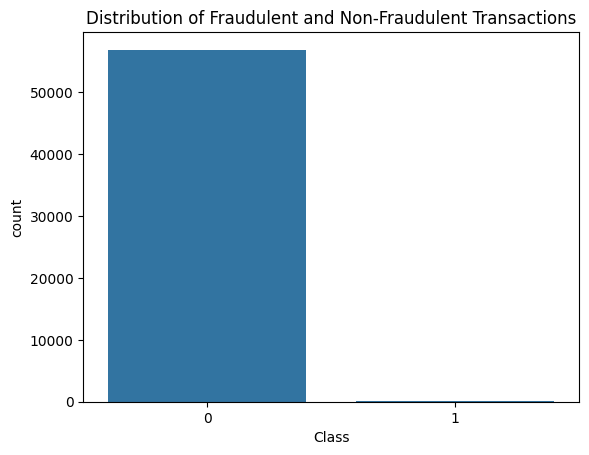

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the Class variable
sns.countplot(x='Class', data=data)
plt.title('Distribution of Fraudulent and Non-Fraudulent Transactions')
plt.show()

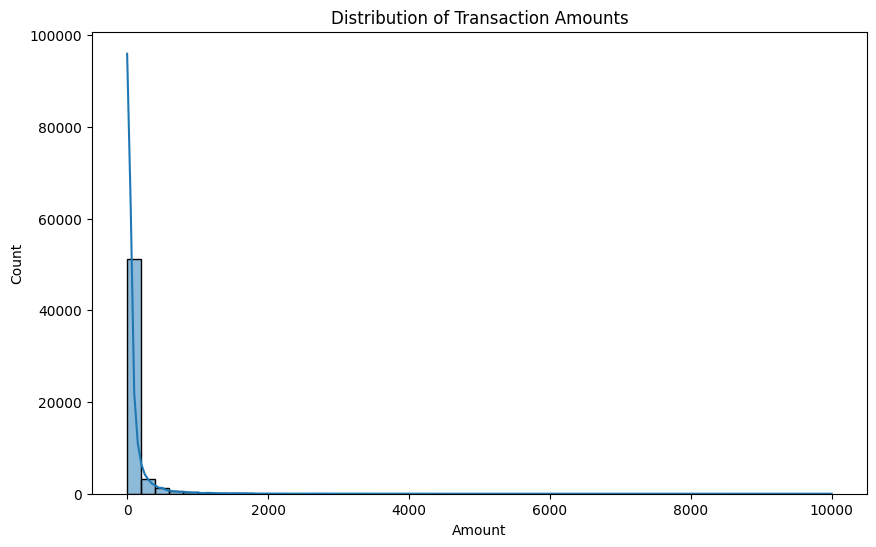

In [ ]:
# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

In [ ]:
fraud_cases = data['Class'].value_counts()
fraud_cases

,count
Class,
0,56863
1,98


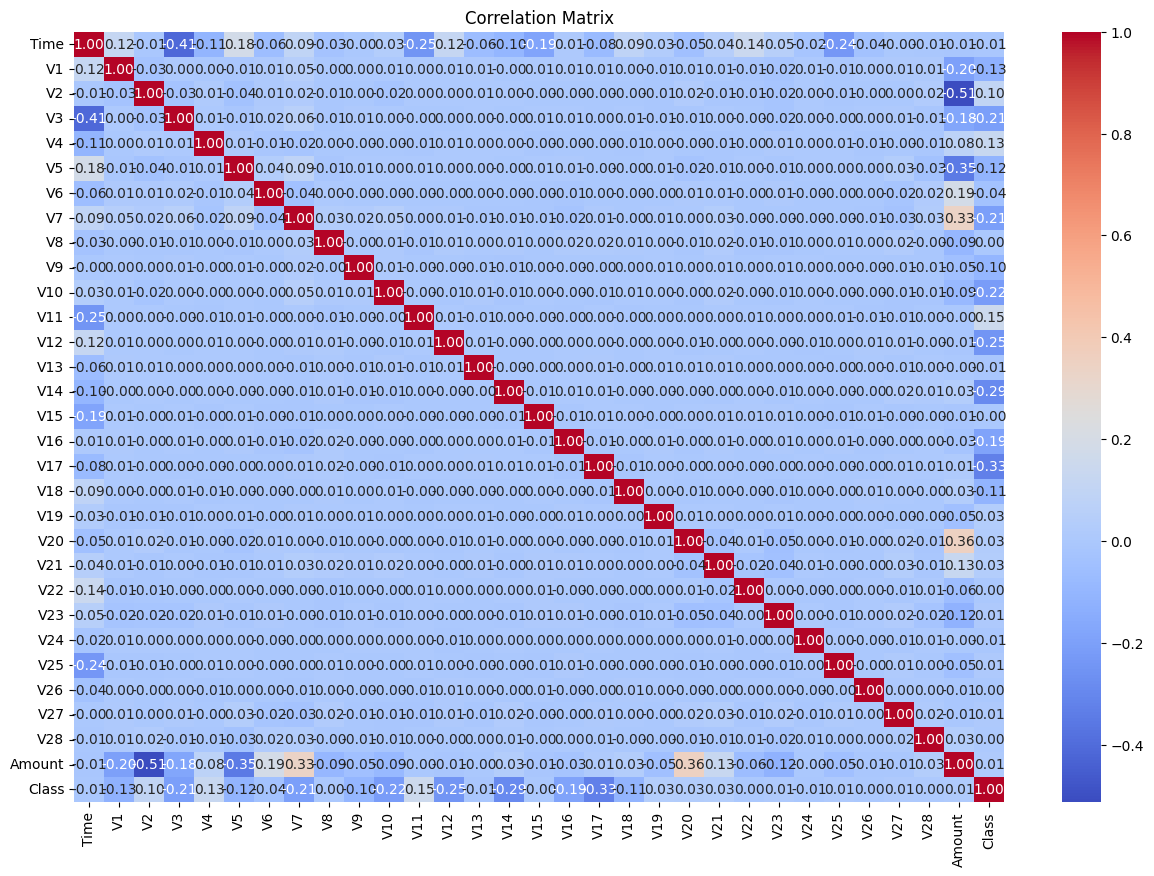

In [ ]:
# Calculate and visualize the correlation matrix
plt.figure(figsize=(15, 10))
correlation = data.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Feature Engineering

#### Feature Scaling and Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the Amount feature
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))

# Scale the V1 to V28 features
data.iloc[:, 1:29] = scaler.fit_transform(data.iloc[:, 1:29])

## Feature Selection

###  Correlation-Based Feature Selection

In [ ]:
# Drop highly correlated features if necessary
# In this case, we'll skip this step as all V features are already PCA transformed

### Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.linear_model import LogisticRegression
!pip install sklearn.feature_selection # install the module
from sklearn.feature_selection import RFE # import the function directly

# Define the model
model = LogisticRegression(solver='liblinear')

# Define RFE
rfe = RFE(estimator=model, n_features_to_select=5)  # Select top 5 features using n_features_to_select
fit = rfe.fit(data.iloc[:, 1:29], data['Class'])

# Display selected features
selected_features = [data.columns[i] for i in range(len(fit.support_)) if fit.support_[i]]
print("Selected Features:", selected_features)

ERROR: Could not find a version that satisfies the requirement sklearn.feature_selection (from versions: none)
ERROR: No matching distribution found for sklearn.feature_selection
Selected Features: ['V3', 'V9', 'V12', 'V13', 'V21']


- The output Selected Features: ['V3', 'V9', 'V12', 'V13', 'V21'] indicates the top features selected by RFE for predicting fraudulent transactions.

### Feature Importance using Random Forest

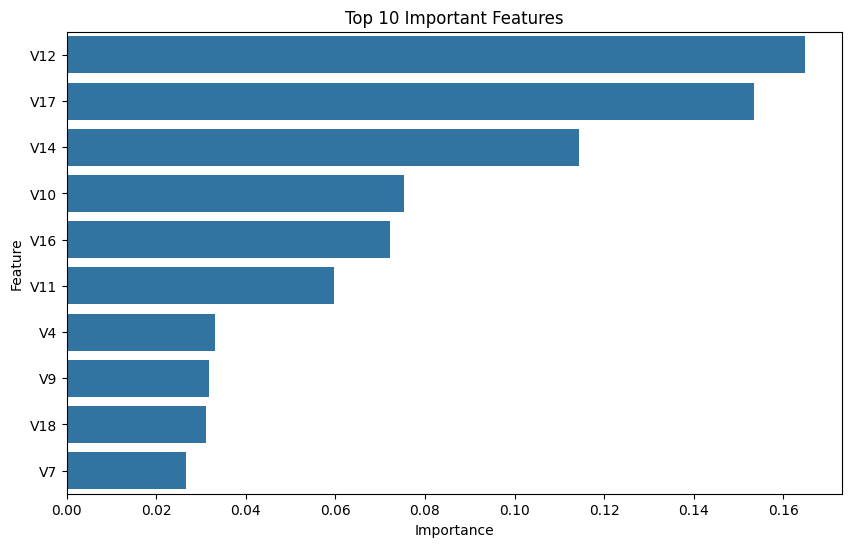

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier()
rf.fit(data.iloc[:, 1:29], data['Class'])

# Display feature importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': data.columns[1:29], 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Important Features')
plt.show()

## Dimensionality Reduction Techniques

### Principal Component Analysis (PCA)

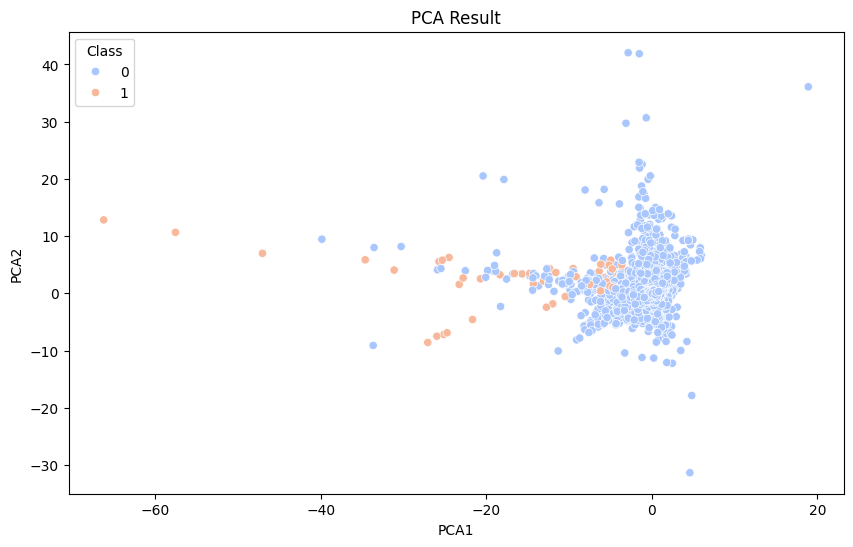

In [ ]:
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data.iloc[:, 1:29])

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PCA1', 'PCA2'])
pca_df['Class'] = data['Class'].values

# Visualize PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Class', data=pca_df, palette='coolwarm')
plt.title('PCA Result')
plt.show()

### t-SNE

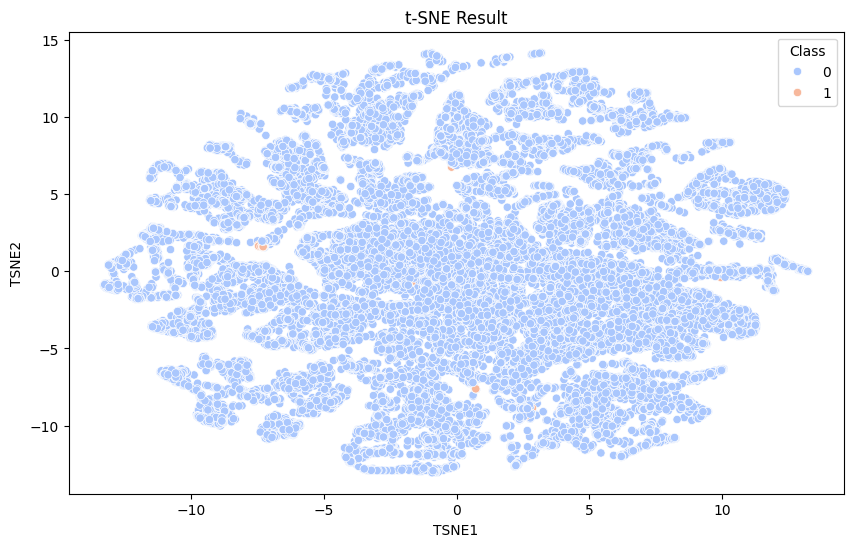

In [ ]:
# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=300)  # Changed n_iter to max_iter
tsne_results = tsne.fit_transform(data.iloc[:, 1:29])  # Adjust column selection as necessary

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['Class'] = data['Class'].values  # Ensure 'Class' is in the original data

# Visualize t-SNE results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Class', data=tsne_df, palette='coolwarm')
plt.title('t-SNE Result')
plt.show()

### Autoencoders for Non-linear Feature Extraction

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense

# Define the Autoencoder model, adjust the input shape to match the data being used
# The input shape should be (28,) since we're using 28 features (columns 1 to 28)
input_layer = Input(shape=(28,))
encoded = Dense(14, activation='relu')(input_layer)
encoded = Dense(7, activation='relu')(encoded)
decoded = Dense(14, activation='relu')(encoded)
# The output layer should also have 28 units to match the input
decoded = Dense(28, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the Autoencoder
# Use data.iloc[:, 1:29] consistently to select the 28 features for both input and output
autoencoder.fit(data.iloc[:, 1:29], data.iloc[:, 1:29], epochs=50, batch_size=256, shuffle=True, validation_split=0.2)

Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.2206 - val_loss: 1.0183
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9817 - val_loss: 0.9763
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9588 - val_loss: 0.9379
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8727 - val_loss: 0.9074
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8817 - val_loss: 0.8889
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8895 - val_loss: 0.8775
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8621 - val_loss: 0.8711
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8454 - val_loss: 0.8657
Epoch 9/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8333 - val_loss: 0.8609
Epoch 10/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8354 - val_loss: 0.8573
Epoch 11/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8301 - val_loss: 0.8547
Epoch 12/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## Anomaly Detection

### Isolation Forest (IF)

In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iforest = IsolationForest(contamination=0.001)
data['IF_Prediction'] = iforest.fit_predict(data.iloc[:, 1:29])

# Count the number of anomalies detected
print("Isolation Forest Anomalies Detected:", len(data[data['IF_Prediction'] == -1]))

Isolation Forest Anomalies Detected: 57


### Local Outlier Factor (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Train LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.001)
data['LOF_Prediction'] = lof.fit_predict(data.iloc[:, 1:29])

# Count the number of anomalies detected
print("Local Outlier Factor Anomalies Detected:", len(data[data['LOF_Prediction'] == -1]))

Local Outlier Factor Anomalies Detected: 57


### One-Class SVM

In [ ]:
from sklearn.svm import OneClassSVM

# Train One-Class SVM
ocsvm = OneClassSVM(gamma='auto', nu=0.001)
data['OCSVM_Prediction'] = ocsvm.fit_predict(data.iloc[:, 1:29])

# Count the number of anomalies detected
print("One-Class SVM Anomalies Detected:", len(data[data['OCSVM_Prediction'] == -1]))

One-Class SVM Anomalies Detected: 555


## Evaluation of Anomaly Detection Models

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, precision_recall_curve

# Assuming 'data' is your DataFrame with the first column as 'Time' and the rest as features

# Train Isolation Forest
iforest = IsolationForest(contamination=0.001, random_state=42)
data['IF_Prediction'] = iforest.fit_predict(data.iloc[:, 1:29])
data['IF_Scores'] = iforest.decision_function(data.iloc[:, 1:29])  # Get decision scores
iforest_anomalies = len(data[data['IF_Prediction'] == -1])

# Train Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.001)
data['LOF_Prediction'] = lof.fit_predict(data.iloc[:, 1:29])
data['LOF_Scores'] = -lof.negative_outlier_factor_  # Get decision scores (inverted)
lof_anomalies = len(data[data['LOF_Prediction'] == -1])

# Train One-Class SVM
ocsvm = OneClassSVM(gamma='auto', nu=0.001)
data['OCSVM_Prediction'] = ocsvm.fit_predict(data.iloc[:, 1:29])
data['OCSVM_Scores'] = ocsvm.decision_function(data.iloc[:, 1:29])  # Get decision scores
ocsvm_anomalies = len(data[data['OCSVM_Prediction'] == -1])

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'True Labels': data['Class'],
    'IF Prediction': data['IF_Prediction'],
    'LOF Prediction': data['LOF_Prediction'],
    'OCSVM Prediction': data['OCSVM_Prediction'],
    'IF Scores': data['IF_Scores'],
    'LOF Scores': data['LOF_Scores'],
    'OCSVM Scores': data['OCSVM_Scores']
})

# Convert predictions to binary
comparison_df['IF Prediction'] = comparison_df['IF Prediction'].apply(lambda x: 1 if x == -1 else 0)
comparison_df['LOF Prediction'] = comparison_df['LOF Prediction'].apply(lambda x: 1 if x == -1 else 0)
comparison_df['OCSVM Prediction'] = comparison_df['OCSVM Prediction'].apply(lambda x: 1 if x == -1 else 0)

# Classification reports
print("Isolation Forest Classification Report:\n", classification_report(comparison_df['True Labels'], comparison_df['IF Prediction']))
print("Local Outlier Factor Classification Report:\n", classification_report(comparison_df['True Labels'], comparison_df['LOF Prediction']))
print("One-Class SVM Classification Report:\n", classification_report(comparison_df['True Labels'], comparison_df['OCSVM Prediction']))

# Calculate AUC-ROC and AUC-PR
roc_auc_if = roc_auc_score(comparison_df['True Labels'], comparison_df['IF Scores'])
roc_auc_lof = roc_auc_score(comparison_df['True Labels'], comparison_df['LOF Scores'])
roc_auc_ocsvm = roc_auc_score(comparison_df['True Labels'], comparison_df['OCSVM Scores'])

pr_auc_if = average_precision_score(comparison_df['True Labels'], comparison_df['IF Scores'])
pr_auc_lof = average_precision_score(comparison_df['True Labels'], comparison_df['LOF Scores'])
pr_auc_ocsvm = average_precision_score(comparison_df['True Labels'], comparison_df['OCSVM Scores'])

# Print AUC-ROC and AUC-PR results
print(f"\nAUC-ROC for Isolation Forest: {roc_auc_if:.4f}")
print(f"AUC-ROC for Local Outlier Factor: {roc_auc_lof:.4f}")
print(f"AUC-ROC for One-Class SVM: {roc_auc_ocsvm:.4f}")

print(f"\nAUC-PR for Isolation Forest: {pr_auc_if:.4f}")
print(f"AUC-PR for Local Outlier Factor: {pr_auc_lof:.4f}")
print(f"AUC-PR for One-Class SVM: {pr_auc_ocsvm:.4f}")


Isolation Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.44      0.26      0.32        98

    accuracy                           1.00     56961
   macro avg       0.72      0.63      0.66     56961
weighted avg       1.00      1.00      1.00     56961

Local Outlier Factor Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

One-Class SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.06      0.36      0.11        98

    accuracy                           0.99     56961
   m